#                                   * Customer Insights – A Statistical Investigation *

# ---------------------------------------------------------------------------------

## Importing libraries

In [1]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [6]:
import seaborn as sns

In [44]:
import warnings
warnings.filterwarnings('ignore')

## Loding the dataset

In [7]:
df = pd.read_csv('US_Customer_Insights_Dataset.csv')

In [192]:
# Top 5 values

df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,2021-09-19,2024-02-09,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,2024-05-04,2024-02-06,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,2024-07-24,2025-02-28,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,2023-12-08,2025-03-29,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,2021-06-12,2022-07-24,139.68,1103


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


#### Changing datatype to date

In [13]:
df['JoinDate']=pd.to_datetime(df['JoinDate'],dayfirst=True)

/var/folders/6t/mrvjk_7110d2r0wjst3rcpkh0000gn/T/ipykernel_91300/2713575329.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['JoinDate']=pd.to_datetime(df['JoinDate'],dayfirst=True)


In [15]:
df['TransactionDate']=pd.to_datetime(df['TransactionDate'],dayfirst=True)

/var/folders/6t/mrvjk_7110d2r0wjst3rcpkh0000gn/T/ipykernel_91300/2065812183.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate']=pd.to_datetime(df['TransactionDate'],dayfirst=True)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                10675 non-null  object        
 1   Name                      10675 non-null  object        
 2   State                     10675 non-null  object        
 3   Education                 10675 non-null  object        
 4   Gender                    10675 non-null  object        
 5   Age                       10675 non-null  int64         
 6   Married                   10675 non-null  object        
 7   NumPets                   10675 non-null  int64         
 8   JoinDate                  10675 non-null  datetime64[ns]
 9   TransactionDate           10675 non-null  datetime64[ns]
 10  MonthlySpend              10675 non-null  float64       
 11  DaysSinceLastInteraction  10675 non-null  int64         
dtypes: datetime64[ns](

In [193]:
# Checking for null value counts

df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

# ---------------------------------------------------------------------------------

# ------------------------------ Descriptive Statistics------------------------------

In [17]:
df.describe()

,Age,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675,10675,10675.000000,10675.000000
mean,49.474567,1.340515,2022-08-16 07:30:40.974238720,2024-02-11 04:17:06.548009216,331.610315,538.469883
min,18.000000,0.000000,2020-01-09 00:00:00,2020-01-11 00:00:00,3.890000,1.000000
25%,35.000000,0.000000,2021-08-10 00:00:00,2023-05-23 00:00:00,165.495000,218.000000
50%,49.000000,1.000000,2022-08-11 00:00:00,2024-05-03 00:00:00,282.110000,445.000000
75%,66.000000,2.000000,2023-08-24 00:00:00,2024-12-25 00:00:00,443.255000,788.500000
max,80.000000,4.000000,2024-12-05 00:00:00,2025-12-07 00:00:00,1740.420000,1791.000000
std,18.221365,1.150849,NaN,NaN,225.799253,398.766747


In [18]:
# Fetch object type Values

df.describe(include = 'object')

,CustomerID,Name,State,Education,Gender,Married
count,10675,10675,10675,10675,10675,10675
unique,1000,990,10,5,3,2
top,CUST10798,Joseph Mcbride,California,Master,Male,No
freq,24,29,1180,2269,3791,5583


In [25]:
# Fetching unique values and their counts for each object-type column

for col in df.describe(include = 'object').columns:
    print(col,'--->',df[col].nunique(),'unique values')
    print(df[col].value_counts())
    print('\n')

CustomerID ---> 1000 unique values
CustomerID
CUST10798    24
CUST10117    22
CUST10386    21
CUST10850    21
CUST10101    21
             ..
CUST10531     3
CUST10415     3
CUST10166     3
CUST10346     3
CUST10095     3
Name: count, Length: 1000, dtype: int64


Name ---> 990 unique values
Name
Joseph Mcbride         29
Michael Wilson         29
Christopher Daniels    25
David Vazquez          24
Sharon Schneider       24
                       ..
Vincent Spencer         3
Mary Padilla            3
Ashley Burns            3
Maria Johnson           3
Ricky Jackson           3
Name: count, Length: 990, dtype: int64


State ---> 10 unique values
State
California    1180
Florida       1152
Ohio          1145
Arizona       1087
New York      1085
Georgia       1080
Washington    1030
Colorado      1014
Texas          997
Illinois       905
Name: count, dtype: int64


Education ---> 5 unique values
Education
Master         2269
Associate      2153
Bachelor       2127
High School    2120
PhD

In [39]:
# Standard deviation, Mean and Median for Age, MonthlySpend, DaysSinceLastInteraction

print('-----Stabdard Deviation-----\n',df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].std(),'\n')
print('-----Mean-----\n',df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].mean(),'\n')
print('-----Median-----\n',df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].median())

-----Stabdard Deviation-----
 Age                          18.221365
MonthlySpend                225.799253
DaysSinceLastInteraction    398.766747
dtype: float64 

-----Mean-----
 Age                          49.474567
MonthlySpend                331.610315
DaysSinceLastInteraction    538.469883
dtype: float64 

-----Median-----
 Age                          49.00
MonthlySpend                282.11
DaysSinceLastInteraction    445.00
dtype: float64


In [43]:
# Finding Mode for categorical variables: Gender, Education and Married

print('-----Mode-----\n\n',df[['Gender', 'Education', 'Married']].mode().iloc[0])

-----Mode-----

 Gender         Male
Education    Master
Married          No
Name: 0, dtype: object


# ---------------------------------------------------------------------------------

# ------------------------------Data Visualization------------------------------

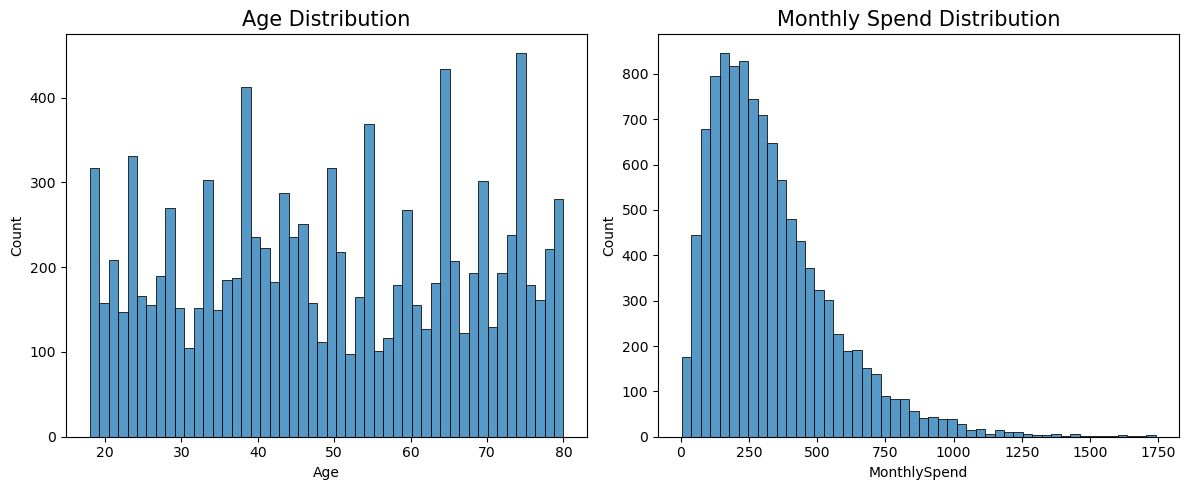

In [93]:

# Ploting histograms for Age and MonthlySpend

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns and width 12, height 5

# Histogram of Age
sns.histplot(data=df, x='Age', bins=50, ax=axes[0])
axes[0].set_title('Age Distribution',size=15)

# Histogram of MonthlySpend
sns.histplot(data=df, x='MonthlySpend', bins=50, ax=axes[1])
axes[1].set_title('Monthly Spend Distribution',size=15)

plt.tight_layout()
plt.show()

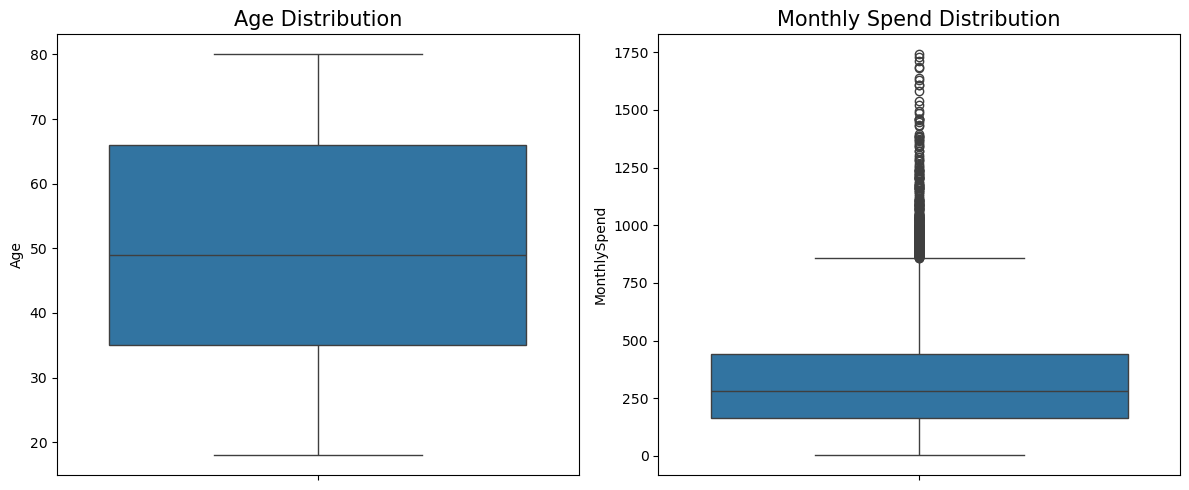

In [88]:
# Ploting boxplot for Age and MonthlySpend

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns and width 12, height 10

# Histogram of Age
sns.boxplot(data=df, y='Age', ax=axes[0])
axes[0].set_title('Age Distribution',size=15)

# Histogram of MonthlySpend
sns.boxplot(data=df, y='MonthlySpend', ax=axes[1])
axes[1].set_title('Monthly Spend Distribution',size=15)

plt.tight_layout()
plt.show()

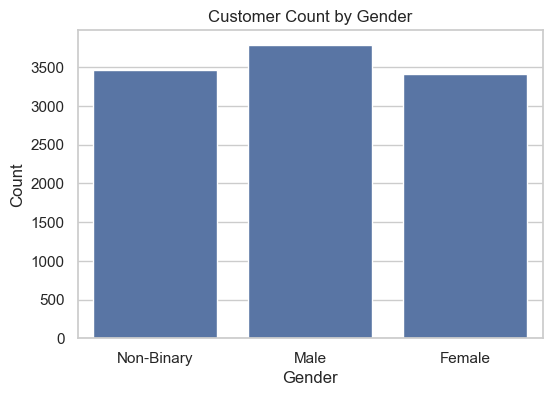

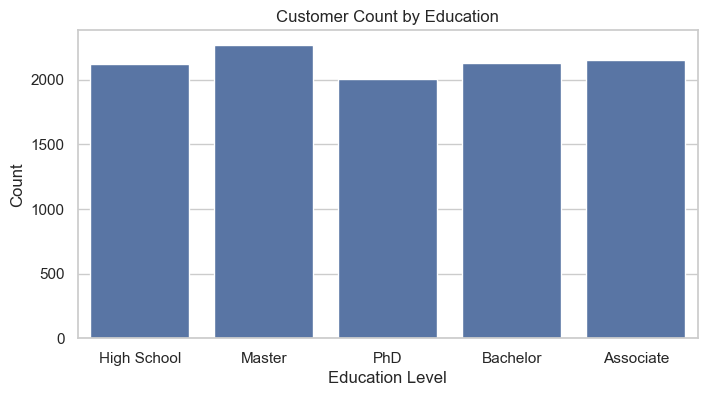

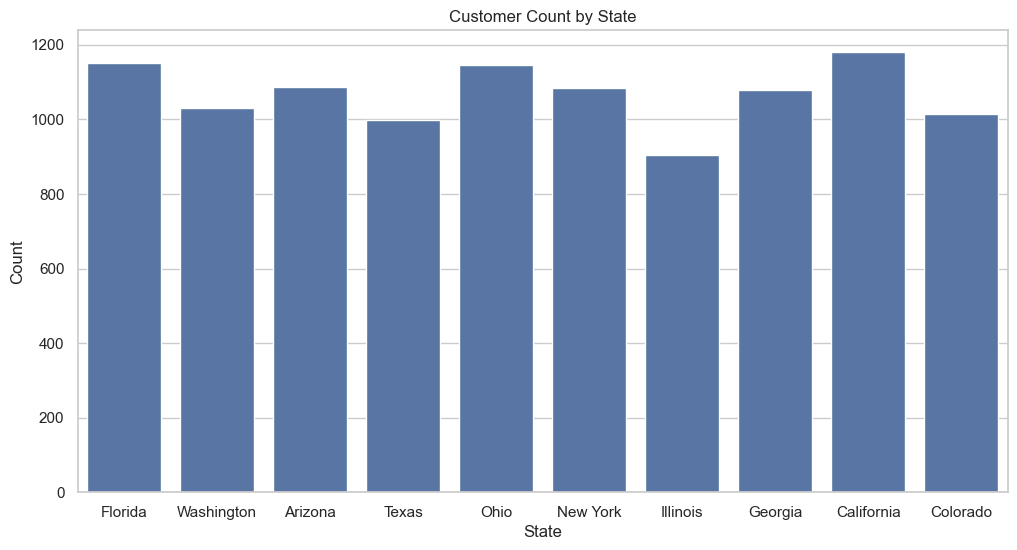

In [112]:
# Ploting bar chart for Gender, Education, State


# Bar chart for Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df , x='Gender')
plt.title('Customer Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Bar chart for Education
plt.figure(figsize=(8,4))
sns.countplot(data=df , x='Education')
plt.title('Customer Count by Education')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

# Bar chart for State
plt.figure(figsize=(12,6))
sns.countplot(data=df , x='State')
plt.title('Customer Count by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.show()

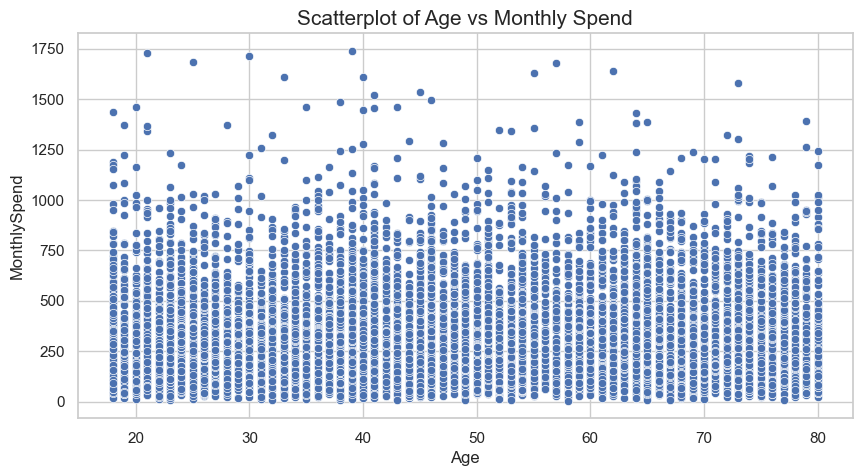

In [120]:
# Scatterplot: Age vs MonthlySpend

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Age', y='MonthlySpend')
plt.title('Scatterplot of Age vs Monthly Spend', fontsize=15)
plt.xlabel('Age')
plt.ylabel('MonthlySpend')
plt.show()

In [127]:
# KDE: Spending behavior by education level or marital status

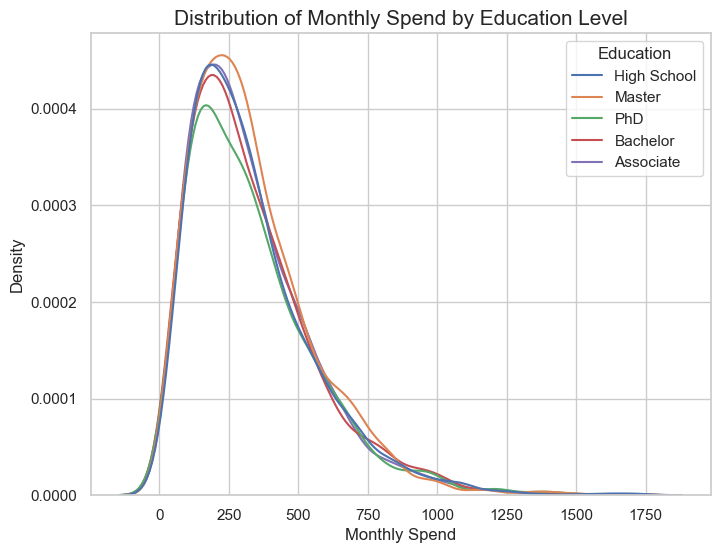

In [191]:
# KDE by Education Level

plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='MonthlySpend', hue='Education')
plt.title('Distribution of Monthly Spend by Education Level', fontsize=15)
plt.xlabel('Monthly Spend')
plt.ylabel('Density')
plt.show()

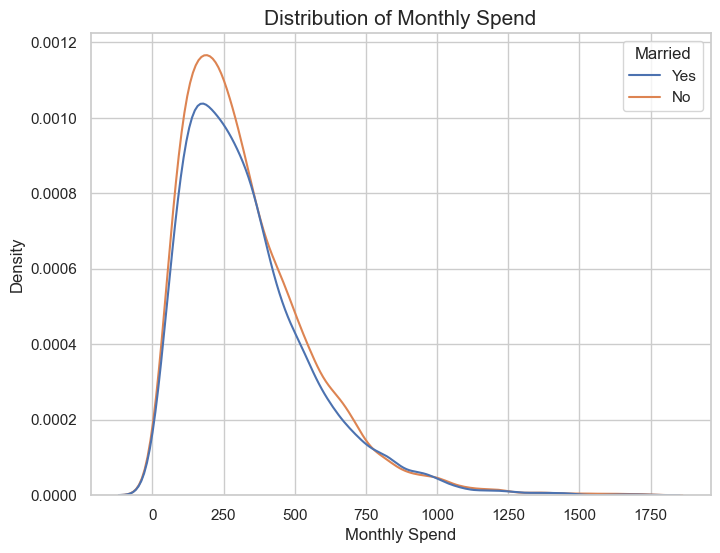

In [190]:
# KDE by Marital Status

plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='MonthlySpend', hue='Married')
plt.title('Distribution of Monthly Spend', fontsize=15)
plt.xlabel('Monthly Spend')
plt.ylabel('Density')
plt.show()

# ---------------------------------------------------------------------------------

# ------------------------------Bivariate Analysis------------------------------

<Axes: >

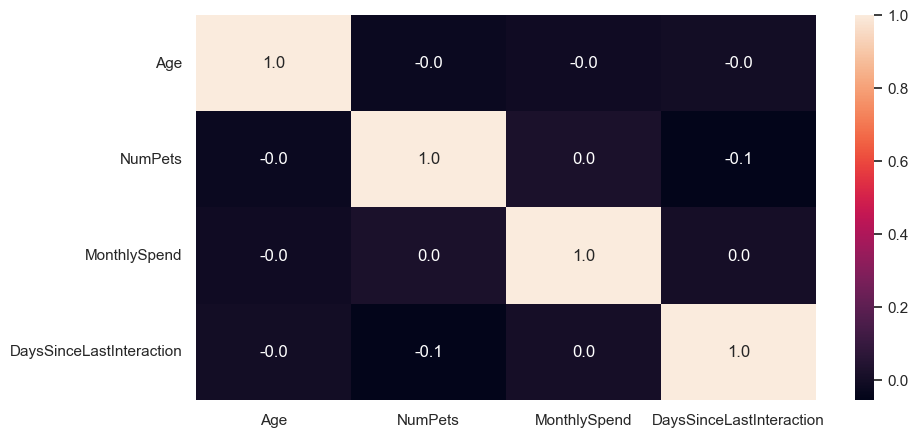

In [136]:
# Correlation matrix (numeric variables)

x = df.select_dtypes(include = 'number') # fetch only numerical columns and store them into x variable
x.corr()    # But it is not readable for this problem we use heat map
plt.figure(figsize=(10,5))
sns.heatmap(x.corr(),annot = True , fmt = '.1f')  # ploting heatmap

In [139]:
# Crosstab of Gender vs Married

pd.crosstab( df['Gender'] , df['Married'] )

Married,No,Yes
Gender,,
Female,1797,1616
Male,1892,1899
Non-Binary,1894,1577


In [147]:
# Grouped stats: average MonthlySpend by State, Education, Gender

# Average MonthlySpend by State
print('Average MonthlySpend by State:')
print(df.groupby('State')['MonthlySpend'].mean())
print('\n') 

# Average MonthlySpend by Education
print('Average MonthlySpend by Education:')
print(df.groupby('Education')['MonthlySpend'].mean())
print('\n')

# Average MonthlySpend by Gender
print('Average MonthlySpend by Gender:')
print(df.groupby('Gender')['MonthlySpend'].mean())

Average MonthlySpend by State:
State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64


Average MonthlySpend by Education:
Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64


Average MonthlySpend by Gender:
Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64


# ---------------------------------------------------------------------------------

# ------------------------------Formulate Hypotheses------------------------------

### 1. Do males and females spend differently? 

In [156]:

# * Null hypothesis (H0): Males and females spend the same on average
# * Alternative hypothesis (H1): Males and females spend differently

from scipy.stats import ttest_ind

In [161]:
# Performing Levene’s test

# * Null hypothesis (H0): Variances are equal between Male and Female
# * Alternative hypothesis (H1): Variances are not equal between Male and Female

from scipy.stats import levene

male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']
l , p = levene(male_spend, female_spend)

print("Levene's test statistic:", s)
print("p-value:", p)

if p > 0.05:
    print("H0 Accepted: Variances are equal between Male and Female")
else:
    print("H0 Rejected: Variances are not equal between Male and Female")

Levene's test statistic: 0.1267563861615179
p-value: 0.7218295518516542
H0 Accepted: Variances are equal between Male and Female


In [163]:
# Performing T-test

male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']
t_stat, p_value = ttest_ind(male_spend, female_spend)  

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("H0 Accepted: Males and females spend the same")
else:
    print("H0 Rejected: Males and females spend differently")

t-statistic: 0.3391730320232445
p-value: 0.7344892727022859
H0 Accepted: Males and females spend the same


### 2. Does education level impact average monthly spend? 

In [168]:
# one-way ANOVA

# * Null hypothesis (H0): The mean MonthlySpend is the same across all education levels.
# * Alternative hypothesis (H1): At least one education level has a different mean MonthlySpend.

from scipy.stats import f_oneway

Associate_spend = df[df['Education'] == 'Associate']['MonthlySpend']
Bachelor_spend = df[df['Education'] == 'Bachelor']['MonthlySpend']
HighSchool_spend = df[df['Education'] == 'High School']['MonthlySpend']
Master_spend = df[df['Education'] == 'Master']['MonthlySpend']
PhD_spend = df[df['Education'] == 'PhD']['MonthlySpend']

f_stat, p_value = f_oneway(Associate_spend , Bachelor_spend , HighSchool_spend , Master_spend , PhD_spend)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("H0 Accepted: Education level does not impacts average MonthlySpend")
else:
    print("H1 Accepted: Education level does impacts average MonthlySpend")

F-statistic: 0.22880668673709165
p-value: 0.922359467759936
H0 Accepted: Education level does not impacts average MonthlySpend


### 3. Is marital status related to the number of pets owned? 

In [171]:
# Creating a Contingency Table

cont_table = pd.crosstab(df['Married'], df['NumPets'])
cont_table

NumPets,0,1,2,3,4
Married,,,,,
No,1839,1435,1504,509,296
Yes,1205,1770,1242,598,277


In [174]:
# Chi-Square test

# * Null hypothesis (H0): Marital status and number of pets are independent.
# * Alternative hypothesis (H1): Marital status and number of pets are related.

from scipy.stats import chi2_contingency

chi2 , p_value , dof , expected = chi2_contingency(cont_table)

print("Chi2 statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

if p_value > 0.05:
    print("\nH0 Accepted: Marital status and number of pets are independent")
else:
    print("\nH1 Accepted: Marital status and number of pets are related")

Chi2 statistic: 177.63953668537033
p-value: 2.3957232932397494e-37
Degrees of freedom: 4
Expected frequencies:
 [[1592.00487119 1676.20749415 1436.15156909  578.95840749  299.67765808]
 [1451.99512881 1528.79250585 1309.84843091  528.04159251  273.32234192]]

H1 Accepted: Marital status and number of pets are related


### 4. Are older people less active? 

In [180]:
# Correlation (Age vs DaysSinceLastInteraction)

correlation = df['Age'].corr(df['DaysSinceLastInteraction'])
correlation

np.float64(-0.003970230104955038)

In [181]:
# conclusion
#There is no significant linear relationship between: Age and DaysSinceLastInteraction

### 5. Does state-wise spend vary significantly? 

In [182]:
# one-way ANOVA

# * Null hypothesis (H0): Mean MonthlySpend is the same across all states
# * Alternative hypothesis (H1): At least one state has a different mean spend

group = df.groupby('State')['MonthlySpend'].apply(list)
group

State
Arizona       [510.34, 175.81, 1225.58, 319.54, 508.64, 66.4...
California    [315.62, 353.14, 920.89, 961.06, 550.22, 247.9...
Colorado      [322.3, 311.23, 153.83, 526.87, 115.6, 184.44,...
Florida       [1281.74, 320.95, 127.75, 121.79, 547.29, 994....
Georgia       [103.3, 331.69, 444.09, 155.06, 637.29, 288.58...
Illinois      [912.8, 249.12, 366.8, 137.27, 203.92, 531.34,...
New York      [320.48, 151.49, 30.5, 439.96, 335.24, 207.73,...
Ohio          [402.96, 172.63, 138.76, 183.55, 433.2, 132.46...
Texas         [396.47, 139.68, 423.45, 444.74, 432.37, 391.5...
Washington    [429.46, 192.79, 391.83, 107.94, 145.35, 285.3...
Name: MonthlySpend, dtype: object

In [183]:
f_stat, p_value = f_oneway(*group)
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("H0 Accepted: Mean MonthlySpend is the same across all states")
else:
    print("H1 Accepted: At least one state has a different mean spend")

F-statistic: 1.1178423640877178
p-value: 0.3457188647924507
H0 Accepted: Mean MonthlySpend is the same across all states


# Normality Test (Shapiro-Wilk test)

In [184]:

# * Null hypothesis (H0): Data is normally distributed
# * Alternative hypothesis (H1): Data is not normally distributed

from scipy.stats import shapiro            # Importing library

stat, p_value = shapiro(df['MonthlySpend'])

print("Shapiro test statistic:", stat)
print("p-value:", p_value)


if p_value > 0.05:
    print("H0 Accepted: Data is normally distributed")
else:
    print("H1 Accepted: Data is not normally distributed")



Shapiro test statistic: 0.8995173951950913
p-value: 8.932895405320401e-64
H1 Accepted: Data is not normally distributed


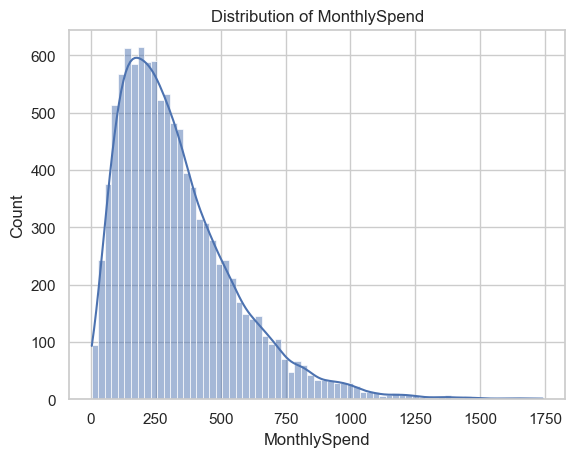

In [185]:
sns.histplot(df['MonthlySpend'], kde=True)
plt.title("Distribution of MonthlySpend")
plt.show()

# Confidence Interval (CI)

In [188]:
import scipy.stats as stats

# CI on MonthlySpend
mean = df['MonthlySpend'].mean()
sem = stats.sem(df['MonthlySpend'])   # Standard Error of Mean
n = len(df['MonthlySpend'])

print("Mean:", mean)
print("SEM:", sem)
print("Sample size:", n)

Mean: 331.61031475409834
SEM: 2.18543834361454
Sample size: 10675


In [195]:
# Calculating CI

CI = stats.t.interval(confidence = 0.95 , df = n-1 , loc = mean , scale =sem)
CI

(np.float64(327.32644854753835), np.float64(335.89418096065833))

# ---------------------------------------------------------------------------------

# -------------------------------Key Business Insights-----------------------------

### 1. Education impacts spending behavior.
   #### * Customer with Master degrees show higher spending patterns.
     
### 2. No significant difference in spending by gender.
   
### 3. Spending varies across states.
   
### 4. Age does not affect how often customers interact.
   
### 5. Marital status and pet ownership are related.
   